# Representation Learning

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5a_DimReduction.ipynb)

A central question in modern machine learning is not only **which model should we fit?** but also:

> What representation of the data will make learning possible, efficient, and meaningful?

A representation is the form in which data are given to a model: raw pixels, engineered features, principal components, learned embeddings, latent variables, or neural network activations. Good representations make useful structure easier to detect. Poor representations can hide structure, exaggerate noise, or make a simple problem look impossible.

In this module, dimensionality reduction appears as one family of representation learning methods. We will study linear representations, nonlinear embeddings, manifold learning, autoencoders, and self-supervised representations.


## Representation learning: the main idea

Suppose a dataset has $n$ observations and $p$ original features:

$$
X \in \mathbb{R}^{n \times p}.
$$

Representation learning creates a new description of the same observations:

$$
X \rightarrow Z,
$$

where $Z$ might have fewer dimensions, more useful coordinates, more separable structure, or less noise.

Sometimes $Z \in \mathbb{R}^{n \times k}$ with $k \ll p$, which is the classic dimensionality reduction setting. But the modern view is broader. A learned representation might also be:

- a two-dimensional visualization for human inspection;
- a compressed code that can reconstruct the input;
- a latent embedding used by a downstream classifier;
- a self-supervised feature vector learned without human labels;
- a set of coordinates that preserves neighborhoods, distances, or class structure.

A good representation depends on the goal. The same embedding may be excellent for visualization, weak for prediction, or misleading for clustering. Our job is to ask what structure the representation preserves, what it distorts, and how we would know whether it is useful.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.datasets import load_digits, load_wine, make_moons, make_swiss_roll
from sklearn.decomposition import PCA, SparsePCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import MDS, Isomap, TSNE
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist

rng = np.random.default_rng(7)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Covariance as geometry

Before PCA, we need one geometric idea: a covariance matrix describes the shape of variation in the data.

- Large diagonal entries mean large variation in individual features.
- Positive off-diagonal entries mean features tend to increase together.
- Negative off-diagonal entries mean one feature tends to increase when the other decreases.
- Eigenvectors point along the main axes of the data cloud.
- Eigenvalues describe how much variation lies along each eigenvector.


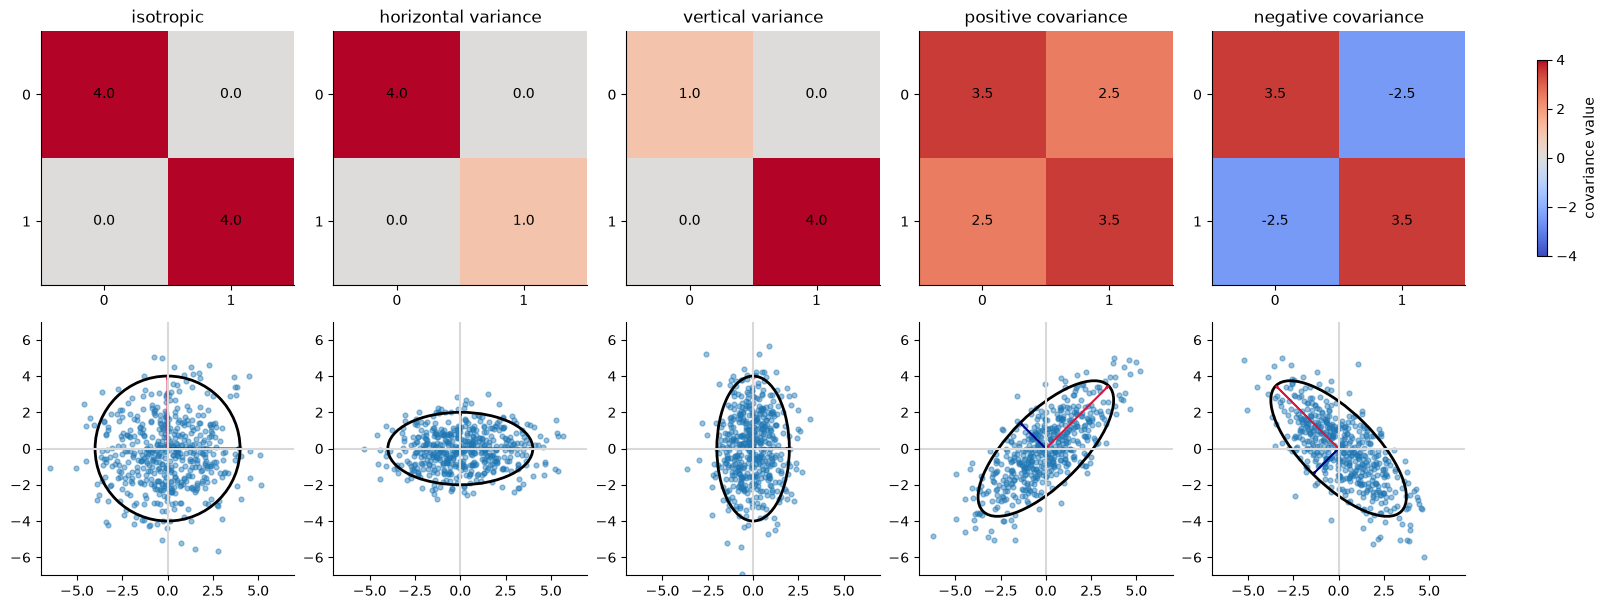

In [2]:
def add_covariance_ellipse(ax, cov, mean=(0, 0), n_std=2, **kwargs):
    values, vectors = np.linalg.eigh(cov)
    order = values.argsort()[::-1]
    values = values[order]
    vectors = vectors[:, order]
    angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(values)
    ellipse = Ellipse(mean, width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ellipse)
    return values, vectors

covs = [
    np.array([[4.0, 0.0], [0.0, 4.0]]),
    np.array([[4.0, 0.0], [0.0, 1.0]]),
    np.array([[1.0, 0.0], [0.0, 4.0]]),
    np.array([[3.5, 2.5], [2.5, 3.5]]),
    np.array([[3.5, -2.5], [-2.5, 3.5]]),
]
case_titles = ['isotropic', 'horizontal variance', 'vertical variance', 'positive covariance', 'negative covariance']
Xs = [rng.multivariate_normal([0, 0], cov, size=500) for cov in covs]

fig, axes = plt.subplots(2, 5, figsize=(16, 6), constrained_layout=True)
for i, (cov, X_case) in enumerate(zip(covs, Xs)):
    im = axes[0, i].imshow(cov, cmap='coolwarm', vmin=-4, vmax=4)
    axes[0, i].set_title(case_titles[i])
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_yticks([0, 1])
    for row in range(2):
        for col in range(2):
            axes[0, i].text(col, row, f'{cov[row, col]:.1f}', ha='center', va='center')

    ax = axes[1, i]
    ax.scatter(X_case[:, 0], X_case[:, 1], s=12, alpha=0.45)
    values, vectors = add_covariance_ellipse(ax, cov, edgecolor='black', linewidth=2)
    for j, color in enumerate(['crimson', 'navy']):
        direction = vectors[:, j] * np.sqrt(values[j]) * 2
        ax.arrow(0, 0, direction[0], direction[1], color=color, width=0.035, length_includes_head=True)
    ax.axhline(0, color='0.85')
    ax.axvline(0, color='0.85')
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect('equal')

fig.colorbar(im, ax=axes[0, :], shrink=0.75, label='covariance value')
plt.show()

### Discussion: reading covariance as geometry

For each panel, answer before looking at the matrix values:

1. Which direction contains the most variation?
2. Are the two features mostly independent, positively related, or negatively related?
3. If you had to keep only one new axis, where would you place it?

That last question is the intuition behind the first principal component.


## Principal Component Analysis

PCA is an **unsupervised**, **linear**, and **global** dimensionality reduction method.

The basic steps are:

1. Center or scale the data when appropriate.
2. Compute the covariance structure of the features.
3. Find the eigenvectors/eigenvalues of the covariance matrix.
4. Keep the top $k$ directions of largest variance.
5. Project the data onto those directions.

PCA can also be interpreted as the best rank-$k$ approximation of the data matrix under squared reconstruction error.


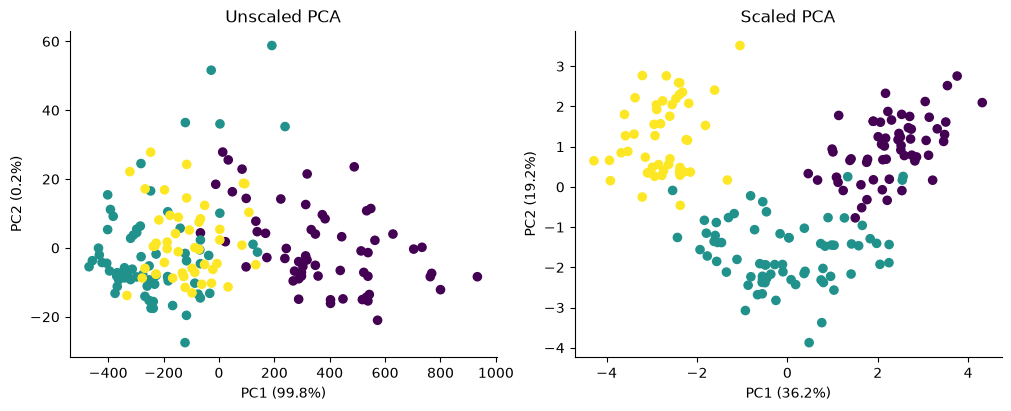

In [3]:
feats, labels = load_wine(return_X_y=True)

pca_unscaled = PCA(n_components=2).fit(feats)
scaled_feats = StandardScaler().fit_transform(feats)
pca_scaled = PCA(n_components=2).fit(scaled_feats)

feats_upc = pca_unscaled.transform(feats)
feats_spc = pca_scaled.transform(scaled_feats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].scatter(feats_upc[:, 0], feats_upc[:, 1], c=labels, cmap='viridis', s=35)
axes[0].set_title('Unscaled PCA')
axes[0].set_xlabel(f'PC1 ({pca_unscaled.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_unscaled.explained_variance_ratio_[1]:.1%})')

axes[1].scatter(feats_spc[:, 0], feats_spc[:, 1], c=labels, cmap='viridis', s=35)
axes[1].set_title('Scaled PCA')
axes[1].set_xlabel(f'PC1 ({pca_scaled.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_scaled.explained_variance_ratio_[1]:.1%})')
plt.show()

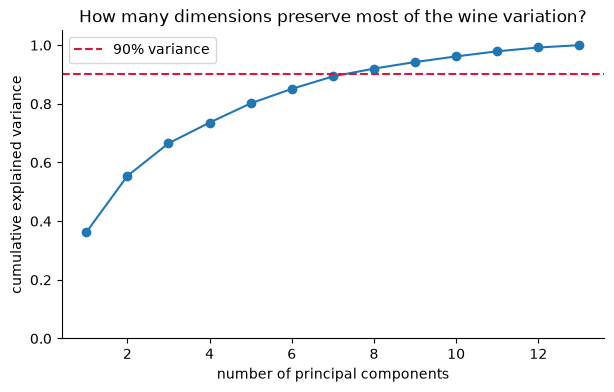

In [4]:
pca_full = PCA().fit(scaled_feats)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        np.cumsum(pca_full.explained_variance_ratio_), marker='o')
ax.axhline(0.90, color='crimson', linestyle='--', label='90% variance')
ax.set_xlabel('number of principal components')
ax.set_ylabel('cumulative explained variance')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('How many dimensions preserve most of the wine variation?')
plt.show()

### Quick exercise: scaling changes the question

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5a_DimReduction.ipynb#scrollTo=ex-scaling-changes-question)

Compare the scaled and unscaled PCA plots.

1. Which plot is dominated by features with large numeric ranges?
2. Which plot treats all original measurements more equally?
3. In a real application, when would the unscaled version be defensible?


## PCA as compression

If we project data down to $k$ components and then project back to the original feature space, we get a compressed reconstruction. The reconstruction improves as $k$ increases, but the representation becomes less compact.


In [5]:
X_digits, y_digits = load_digits(return_X_y=True)
X_digits = X_digits / 16.0

def plot_digit_reconstruction(n_components=8, digit_index=0):
    pca = PCA(n_components=n_components, random_state=0)
    Z = pca.fit_transform(X_digits)
    X_hat = pca.inverse_transform(Z)
    explained = pca.explained_variance_ratio_.sum()

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
    axes[0].imshow(X_digits[digit_index].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[0].set_title('original')
    axes[1].imshow(X_hat[digit_index].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[1].set_title(f'{n_components} PCs')
    axes[2].plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title(f'variance kept: {explained:.1%}')
    axes[2].set_xlabel('component')
    axes[2].set_ylabel('cumulative variance')
    for ax in axes[:2]:
        ax.set_axis_off()
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        plot_digit_reconstruction,
        n_components=widgets.IntSlider(value=8, min=1, max=40, step=1),
        digit_index=widgets.IntSlider(value=0, min=0, max=40, step=1),
    )
except Exception:
    plot_digit_reconstruction(n_components=8, digit_index=0)

interactive(children=(IntSlider(value=8, description='n_components', max=40, min=1), IntSlider(value=0, descri…

### Exercise: compression tradeoff

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5a_DimReduction.ipynb#scrollTo=ex-compression-tradeoff)

Move the number of components up and down.

1. Around how many components does the digit become recognizable?
2. Around how many components do improvements become hard to see?
3. How would your answer change if the downstream task were human inspection, storage, or classification?


## Linear variants: PCA, sparse PCA, and LDA

PCA does not use labels. Sparse PCA encourages components that use fewer original variables. LDA uses labels and therefore answers a different question: which directions separate known classes?


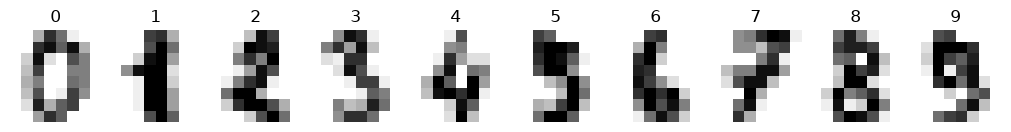

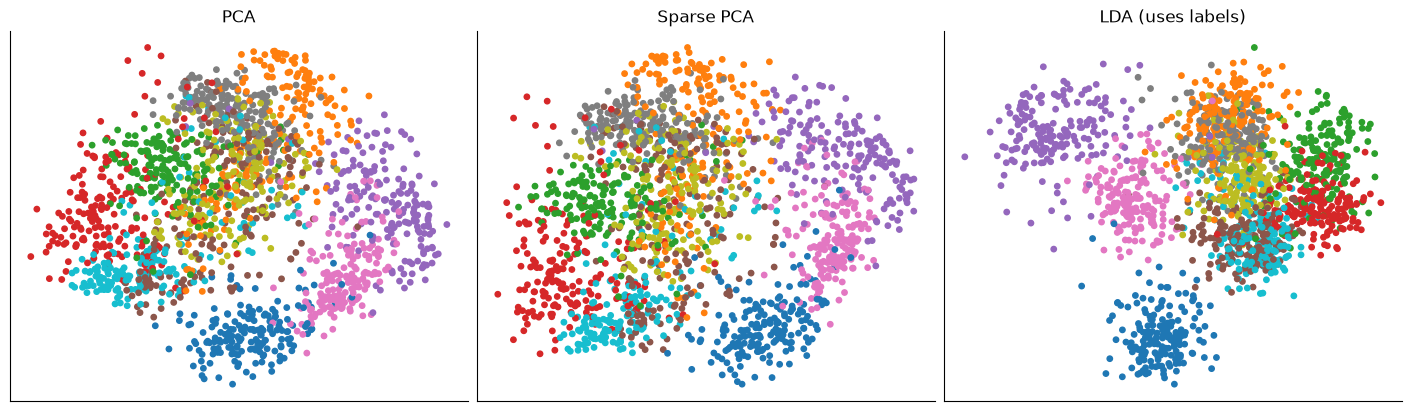

In [6]:
fig, axes = plt.subplots(1, 10, figsize=(10, 1.2), constrained_layout=True)
for i, ax in enumerate(axes):
    ax.imshow(X_digits[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(str(y_digits[i]))
    ax.set_axis_off()
plt.show()

k = 2
X_pca_digits = PCA(n_components=k, random_state=0).fit_transform(X_digits)
X_sparse_digits = SparsePCA(n_components=k, random_state=0, alpha=0.4).fit_transform(X_digits)
X_lda_digits = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_digits, y_digits)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, Z, title in zip(
    axes,
    [X_pca_digits, X_sparse_digits, X_lda_digits],
    ['PCA', 'Sparse PCA', 'LDA (uses labels)'],
):
    ax.scatter(Z[:, 0], Z[:, 1], c=y_digits, cmap='tab10', s=15)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

### Discussion: same data, different objective

1. Which method produces the clearest class separation?
2. Why is that not a fair comparison if the goal is unsupervised discovery?
3. What would make sparse PCA preferable to ordinary PCA?


## Beyond linear PCA

PCA works well when the important structure is approximately linear. Many real datasets have nonlinear structure: curves, loops, surfaces, or neighborhoods that do not unfold cleanly with a straight projection.


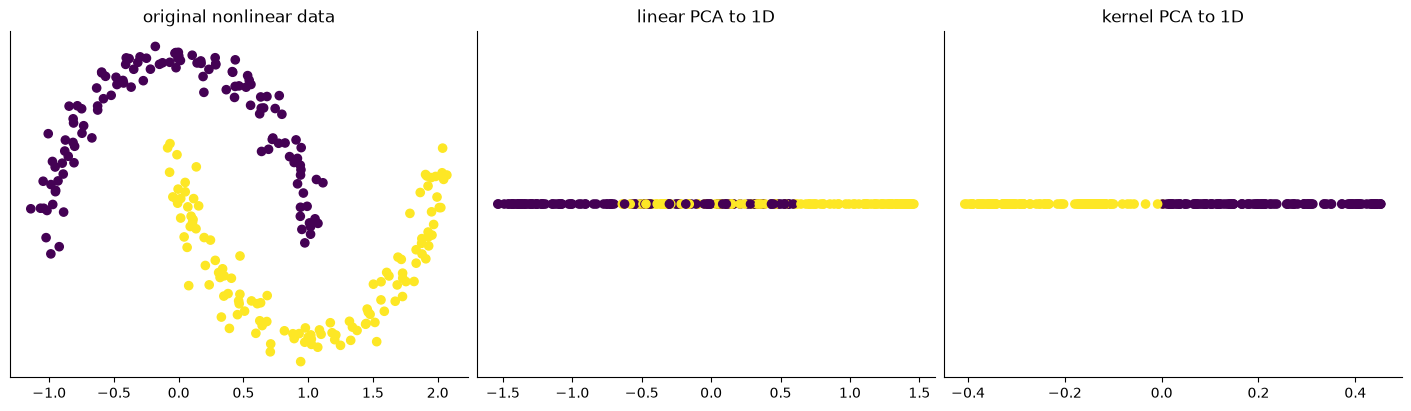

In [7]:
X_moons, y_moons = make_moons(n_samples=250, noise=0.06, random_state=0)

linear_pca = PCA(n_components=1)
kernel_pca = KernelPCA(n_components=1, kernel='rbf', gamma=15, fit_inverse_transform=True)

X_moon_pca = linear_pca.fit_transform(X_moons)
X_moon_kpca = kernel_pca.fit_transform(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=35)
axes[0].set_title('original nonlinear data')
axes[1].scatter(X_moon_pca[:, 0], np.zeros_like(X_moon_pca[:, 0]), c=y_moons, cmap='viridis', s=35)
axes[1].set_title('linear PCA to 1D')
axes[2].scatter(X_moon_kpca[:, 0], np.zeros_like(X_moon_kpca[:, 0]), c=y_moons, cmap='viridis', s=35)
axes[2].set_title('kernel PCA to 1D')
for ax in axes:
    ax.set_yticks([])
plt.show()

In [8]:
def kernel_pca_gamma_demo(gamma=5.0):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    Z = kpca.fit_transform(X_moons)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=35)
    axes[0].set_title('original')
    axes[1].scatter(Z[:, 0], Z[:, 1], c=y_moons, cmap='viridis', s=35)
    axes[1].set_title(f'RBF kernel PCA, gamma={gamma:.1f}')
    for ax in axes:
        ax.set_aspect('equal', adjustable='box')
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(kernel_pca_gamma_demo, gamma=widgets.FloatSlider(value=5.0, min=0.1, max=30.0, step=0.5))
except Exception:
    kernel_pca_gamma_demo(gamma=5.0)

interactive(children=(FloatSlider(value=5.0, description='gamma', max=30.0, min=0.1, step=0.5), Output()), _do…

### Discussion: kernels add flexibility and risk

1. What gamma values separate the moons most clearly?
2. What gamma values start to make the representation look unstable or overly local?
3. Why might a visually beautiful embedding still be a poor choice for a later model?


## Manifold learning

PCA assumes that the important low-dimensional structure can be captured by a flat linear subspace. Manifold learning starts from a different assumption:

> The data may live on a low-dimensional **curved surface** inside a higher-dimensional space.

A classic example is the swiss roll. The data are three-dimensional, but if we could unroll the sheet, two coordinates would describe the position on the surface. The challenge is that Euclidean distance in the original space can be misleading: two points may be close through the air but far apart if we travel along the surface.

Manifold methods try to preserve neighborhood structure rather than global variance. This makes them powerful for visualization, but also easy to over-interpret.


### Isomap: preserve distances along the manifold

**Isomap** stands for *Isometric Mapping*. It tries to preserve distances measured **along the data manifold**, not straight-line Euclidean distances through the original space.

The algorithm has three main steps:

1. Build a neighborhood graph. Connect each point to its nearest neighbors.
2. Estimate geodesic distances. Compute shortest-path distances through the graph.
3. Embed the points in low dimensions using multidimensional scaling (MDS).

If $x_i$ and $x_j$ are two high-dimensional points, ordinary Euclidean distance is

$$
d_E(i,j) = \lVert x_i - x_j \rVert_2.
$$

Isomap replaces this with a graph-based geodesic distance

$$
d_G(i,j) = \text{shortest path distance between } i \text{ and } j \text{ on the neighborhood graph}.
$$

Then Isomap looks for low-dimensional coordinates $z_i$ whose pairwise distances match the graph distances:

$$
\min_{z_1, \ldots, z_n} \sum_{i < j} \left(d_G(i,j) - \lVert z_i - z_j \rVert_2 \right)^2.
$$

The intuition: if the graph captures the surface correctly, shortest paths through the graph approximate distances along the curved manifold.

Important cautions:

- If the neighborhood graph is too sparse, the graph may disconnect.
- If it is too dense, Isomap may create shortcuts across folds in the manifold.
- Isomap is sensitive to noise and sampling density.
- The embedding is primarily a visualization/exploration tool, not automatic proof of true structure.


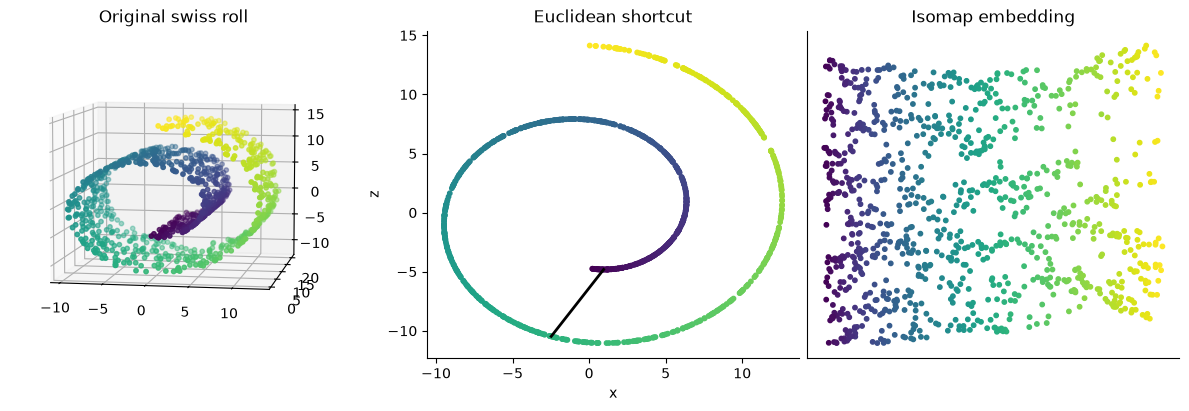

In [9]:
swiss_roll, t = make_swiss_roll(n_samples=1000, random_state=42)

fig = plt.figure(figsize=(12, 4), constrained_layout=True)
ax = fig.add_subplot(131, projection='3d')
ax.scatter(swiss_roll[:, 0], swiss_roll[:, 1], swiss_roll[:, 2], c=t, s=10, cmap='viridis')
ax.view_init(elev=7, azim=-80)
ax.set_title('Original swiss roll')

# Show why straight-line distance can be misleading on a folded surface.
x1 = swiss_roll[10]
x2 = swiss_roll[200]
ax = fig.add_subplot(132)
ax.scatter(swiss_roll[:, 0], swiss_roll[:, 2], c=t, s=10, cmap='viridis')
ax.plot([x1[0], x2[0]], [x1[2], x2[2]], c='black', linewidth=2)
ax.set_title('Euclidean shortcut')
ax.set_xlabel('x')
ax.set_ylabel('z')

swiss_unroll = Isomap(n_components=2, n_neighbors=10).fit_transform(swiss_roll)
ax = fig.add_subplot(133)
ax.scatter(swiss_unroll[:, 0], swiss_unroll[:, 1], c=t, s=10, cmap='viridis')
ax.set_title('Isomap embedding')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [10]:
def isomap_neighbors_demo(n_neighbors=10):
    embedding = Isomap(n_components=2, n_neighbors=n_neighbors).fit_transform(swiss_roll)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=t, s=10, cmap='viridis')
    ax.set_title(f'Isomap with n_neighbors={n_neighbors}')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        isomap_neighbors_demo,
        n_neighbors=widgets.IntSlider(value=10, min=3, max=30, step=1),
    )
except Exception:
    isomap_neighbors_demo(n_neighbors=10)

interactive(children=(IntSlider(value=10, description='n_neighbors', max=30, min=3), Output()), _dom_classes=(…

### Isomap discussion prompts

1. What happens when the number of neighbors is too small?
2. What happens when it is too large?
3. Why does Isomap need enough samples across the whole manifold?
4. When might Euclidean distance be a poor proxy for meaningful similarity?


### t-SNE: preserve local neighborhoods probabilistically

**t-SNE** stands for *t-distributed stochastic neighbor embedding*. It is mainly used for visualization. Its goal is not to preserve all pairwise distances. Instead, it tries to preserve **local neighborhoods**.

The first step converts high-dimensional distances into conditional probabilities. Points near $x_i$ receive high probability; far-away points receive low probability:

$$
p_{j|i} = \frac{\exp\left(-\lVert x_i - x_j \rVert^2 / 2\sigma_i^2\right)}{\sum_{k \ne i} \exp\left(-\lVert x_i - x_k \rVert^2 / 2\sigma_i^2\right)}.
$$

These are usually symmetrized into joint probabilities $p_{ij}$. In the low-dimensional map, t-SNE defines similar probabilities using a heavy-tailed Student-$t$ distribution:

$$
q_{ij} = \frac{\left(1 + \lVert z_i - z_j \rVert^2\right)^{-1}}{\sum_{k \ne l} \left(1 + \lVert z_k - z_l \rVert^2\right)^{-1}}.
$$

Then t-SNE chooses low-dimensional coordinates $z_i$ by minimizing the Kullback-Leibler divergence between the high-dimensional neighborhood probabilities and low-dimensional neighborhood probabilities:

$$
\mathrm{KL}(P \Vert Q) = \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}.
$$

The intuition: if two points were neighbors in the original space, t-SNE strongly penalizes placing them far apart in the embedding.

Important cautions:

- t-SNE is stochastic; different random seeds can produce different maps.
- Distances between far-apart clusters are not reliably meaningful.
- Cluster sizes in the plot are not necessarily meaningful.
- The `perplexity` parameter controls the effective neighborhood size.
- t-SNE is a visualization tool, not a clustering algorithm by itself.


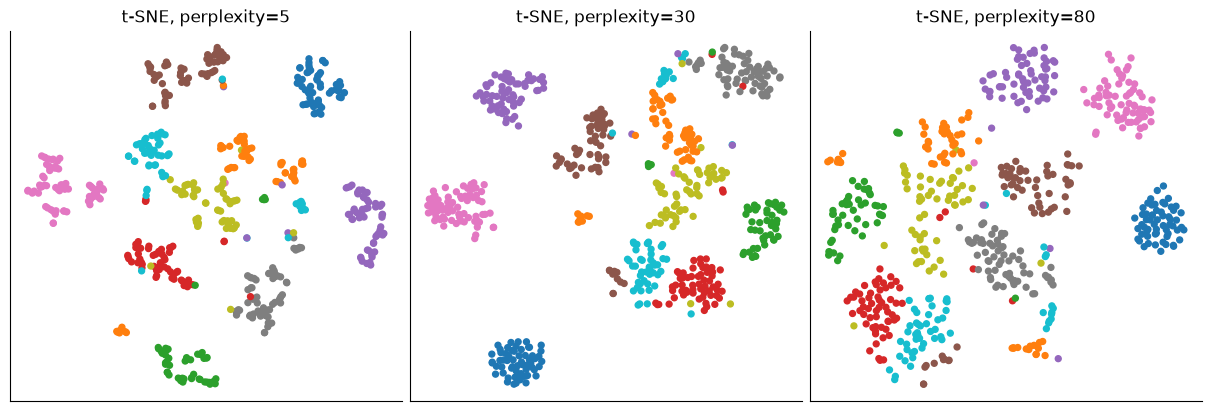

In [11]:
def run_tsne(data, **kwargs):
    try:
        return TSNE(max_iter=1000, **kwargs).fit_transform(data)
    except TypeError:
        return TSNE(n_iter=1000, **kwargs).fit_transform(data)

idx = np.arange(0, len(X_digits), 3)
X_small = X_digits[idx]
y_small = y_digits[idx]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
X_tsne_digits = None
for ax, perplexity in zip(axes, [5, 30, 80]):
    Z = run_tsne(
        X_small,
        n_components=2,
        perplexity=perplexity,
        early_exaggeration=12.0,
        learning_rate=200.0,
        init='random',
        random_state=0,
    )
    if perplexity == 30:
        X_tsne_digits = Z
    ax.scatter(Z[:, 0], Z[:, 1], c=y_small, cmap='tab10', s=18)
    ax.set_title(f't-SNE, perplexity={perplexity}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [12]:
def tsne_seed_demo(random_state=0, perplexity=30):
    Z = run_tsne(
        X_small,
        n_components=2,
        perplexity=perplexity,
        early_exaggeration=12.0,
        learning_rate=200.0,
        init='random',
        random_state=random_state,
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(Z[:, 0], Z[:, 1], c=y_small, cmap='tab10', s=18)
    ax.set_title(f't-SNE: perplexity={perplexity}, seed={random_state}')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        tsne_seed_demo,
        random_state=widgets.IntSlider(value=0, min=0, max=10, step=1),
        perplexity=widgets.IntSlider(value=30, min=5, max=80, step=5),
    )
except Exception:
    tsne_seed_demo(random_state=0, perplexity=30)

interactive(children=(IntSlider(value=0, description='random_state', max=10), IntSlider(value=30, description=…

### t-SNE discussion prompts

1. Which structures appear stable as perplexity changes?
2. Which parts of the plot move around or change shape?
3. Why should we be careful about saying one t-SNE cluster is "farther" from another?
4. What follow-up analysis would you run before claiming that a t-SNE cluster is a meaningful subgroup?


### Further reading

- Isomap original paper: Tenenbaum, de Silva, and Langford, ["A Global Geometric Framework for Nonlinear Dimensionality Reduction"](https://pubmed.ncbi.nlm.nih.gov/11125149/), *Science*, 2000.
- t-SNE original paper: van der Maaten and Hinton, ["Visualizing Data using t-SNE"](https://www.jmlr.org/papers/v9/vandermaaten08a.html), *JMLR*, 2008.
- Scikit-learn user guide: [Manifold learning](https://scikit-learn.org/stable/modules/manifold.html).
- Scikit-learn API docs: [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html) and [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).
- Laurens van der Maaten's t-SNE page: [t-SNE resources and implementations](https://lvdmaaten.github.io/tsne/).


## Comparing methods

No dimensionality reduction method preserves everything. The question is what distortion is acceptable for the task.


/home/aandre1/ws/learningfromdata-course/venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


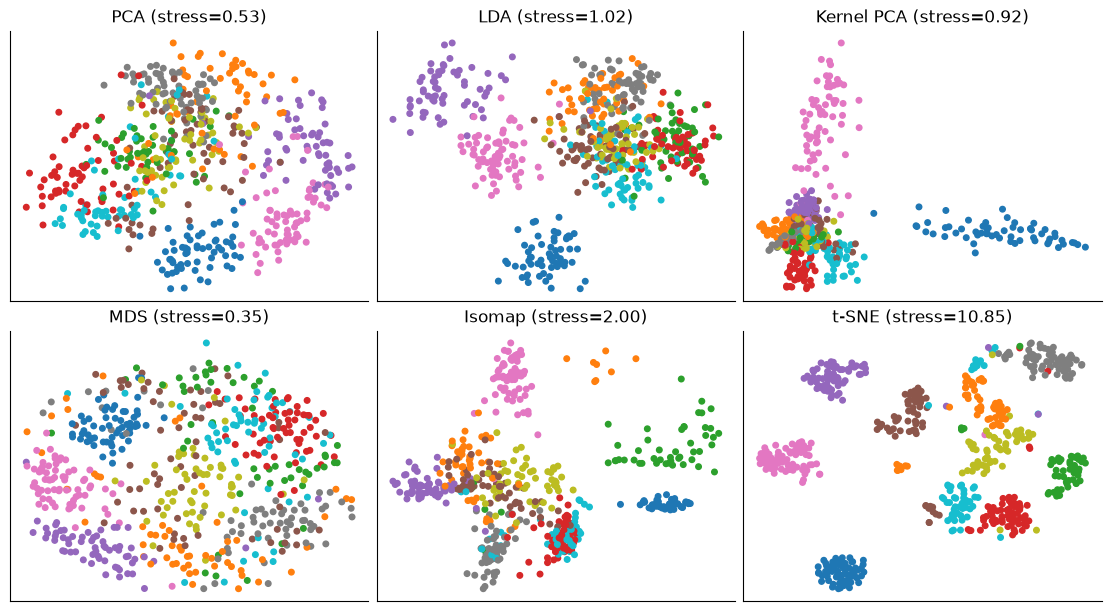

In [13]:
def stress(X_reduced, X_original):
    D_red = pdist(X_reduced)
    D_tot = pdist(X_original)
    return np.sqrt(np.sum((D_tot - D_red) ** 2) / np.sum(D_tot ** 2))

X_pca = PCA(n_components=2, random_state=0).fit_transform(X_small)
X_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_small, y_small)
X_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.5).fit_transform(X_small)
X_mds = MDS(n_components=2, n_init=1, max_iter=100, random_state=0).fit_transform(X_small)
X_iso = Isomap(n_components=2).fit_transform(X_small)
X_tsne = X_tsne_digits

embeddings = [
    ('PCA', X_pca),
    ('LDA', X_lda),
    ('Kernel PCA', X_kpca),
    ('MDS', X_mds),
    ('Isomap', X_iso),
    ('t-SNE', X_tsne),
]

fig, axes = plt.subplots(2, 3, figsize=(11, 6), constrained_layout=True)
for ax, (name, Z) in zip(axes.ravel(), embeddings):
    ax.scatter(Z[:, 0], Z[:, 1], c=y_small, cmap='tab10', s=16)
    ax.set_title(f'{name} (stress={stress(Z, X_small):.2f})')
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## Autoencoders: learning representations by reconstruction

An **autoencoder** is a neural network trained to reproduce its input. It has two parts:

$$
\text{encoder: } x \rightarrow z
$$

$$
\text{decoder: } z \rightarrow \hat{x}
$$

The middle vector $z$ is the learned representation, often called a **latent representation** or **embedding**. If $z$ has fewer dimensions than $x$, the model has to compress the input and keep the information that is most useful for reconstruction.

Autoencoders are a simple example of **self-supervised learning**: we do not need human labels because the target is created from the input itself.

$$
\text{input image} \rightarrow \text{compressed latent code} \rightarrow \text{reconstructed image}
$$

Compared with PCA, autoencoders can learn nonlinear representations. The tradeoff is that they require architecture choices, optimization, and validation.


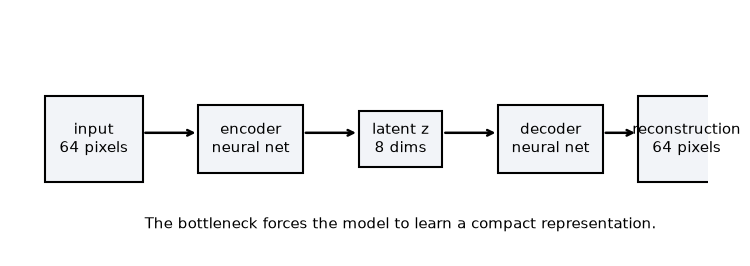

In [14]:
#| code-fold: true
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.5, 1.2, 1.4, 1.4, 'input\n64 pixels'),
    (2.7, 1.35, 1.5, 1.1, 'encoder\nneural net'),
    (5.0, 1.45, 1.2, 0.9, 'latent z\n8 dims'),
    (7.0, 1.35, 1.5, 1.1, 'decoder\nneural net'),
    (9.0, 1.2, 1.4, 1.4, 'reconstruction\n64 pixels'),
]

for x, y, w, h, text in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=True, facecolor='#f2f4f8', edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=11)

for x1, x2 in [(1.9, 2.7), (4.2, 5.0), (6.2, 7.0), (8.5, 9.0)]:
    ax.annotate('', xy=(x2, 2), xytext=(x1, 2), arrowprops=dict(arrowstyle='->', linewidth=1.8))

ax.text(5.6, 0.45, 'The bottleneck forces the model to learn a compact representation.', ha='center', fontsize=11)
plt.show()

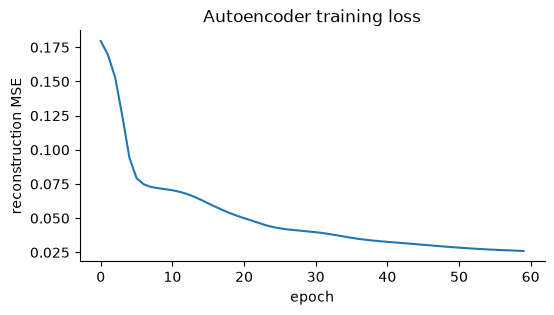

In [15]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Reuse the digits data from earlier in the notebook.
X_digits_tensor = torch.tensor(X_digits, dtype=torch.float32)
y_digits_tensor = torch.tensor(y_digits, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X_digits_tensor,
    y_digits_tensor,
    test_size=0.25,
    random_state=0,
    stratify=y_digits_tensor,
)

train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=128, shuffle=True)

class TinyAutoencoder(nn.Module):
    def __init__(self, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

latent_dim = 8
autoencoder = TinyAutoencoder(latent_dim=latent_dim)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loss_history = []
for epoch in range(60):
    autoencoder.train()
    epoch_loss = 0.0
    for batch_x, _ in train_loader:
        optimizer.zero_grad()
        reconstructed = autoencoder(batch_x)
        loss = loss_fn(reconstructed, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    loss_history.append(epoch_loss / len(train_loader.dataset))

plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('reconstruction MSE')
plt.title('Autoencoder training loss')
plt.show()

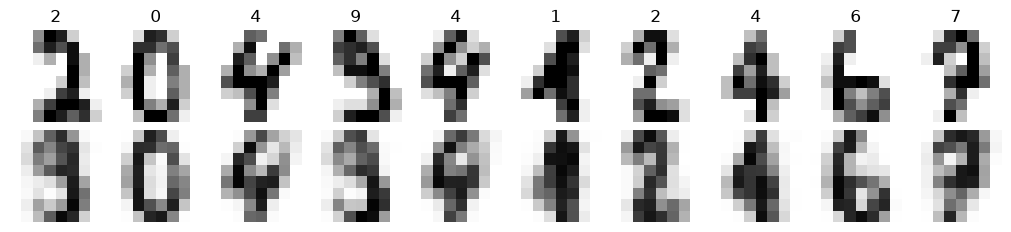

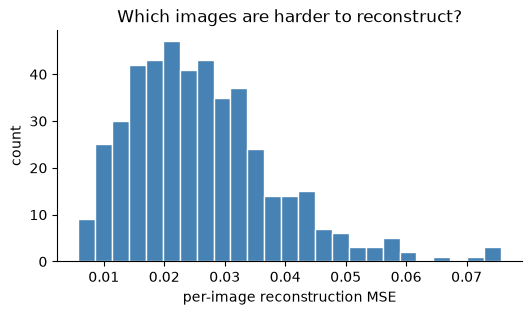

In [16]:
#| code-fold: true
autoencoder.eval()
with torch.no_grad():
    reconstructed_test = autoencoder(X_test[:10]).numpy()
    all_reconstructed = autoencoder(X_test).numpy()

fig, axes = plt.subplots(2, 10, figsize=(10, 2.2), constrained_layout=True)
for i in range(10):
    axes[0, i].imshow(X_test[i].numpy().reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].set_title(str(y_test[i].item()))
    axes[1, i].imshow(reconstructed_test[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].set_axis_off()
    axes[1, i].set_axis_off()
axes[0, 0].set_ylabel('original')
axes[1, 0].set_ylabel('recon')
plt.show()

reconstruction_error = np.mean((X_test.numpy() - all_reconstructed) ** 2, axis=1)
plt.figure(figsize=(6, 3))
plt.hist(reconstruction_error, bins=25, color='steelblue', edgecolor='white')
plt.xlabel('per-image reconstruction MSE')
plt.ylabel('count')
plt.title('Which images are harder to reconstruct?')
plt.show()

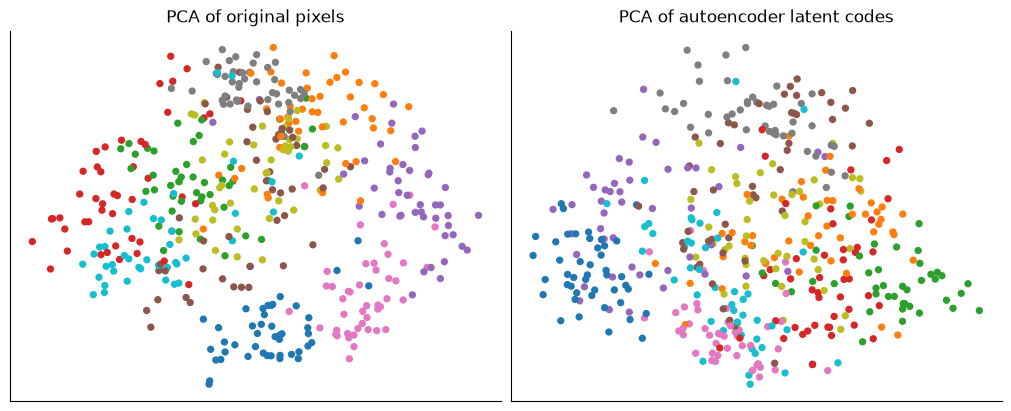

In [17]:
with torch.no_grad():
    Z_test_autoencoder = autoencoder.encoder(X_test).numpy()

Z_test_autoencoder_2d = PCA(n_components=2, random_state=0).fit_transform(Z_test_autoencoder)
X_test_pca_2d = PCA(n_components=2, random_state=0).fit_transform(X_test.numpy())

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].scatter(X_test_pca_2d[:, 0], X_test_pca_2d[:, 1], c=y_test, cmap='tab10', s=18)
axes[0].set_title('PCA of original pixels')
axes[1].scatter(Z_test_autoencoder_2d[:, 0], Z_test_autoencoder_2d[:, 1], c=y_test, cmap='tab10', s=18)
axes[1].set_title('PCA of autoencoder latent codes')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

### Discussion: what did the autoencoder learn?

The autoencoder was not told which digit each image represented. It only learned to reconstruct input images.

Discuss:

1. What information must the latent vector keep in order to reconstruct the digit?
2. What information might it safely ignore?
3. How is this similar to PCA?
4. How is it different from PCA?
5. Does the latent visualization show class structure, reconstruction structure, or both?


## Self-supervised representations and linear probes

In self-supervised learning, we train a model on a task where the supervision comes from the data itself. Examples include reconstructing an input, predicting a missing part of an image or sentence, matching two augmented views of the same object, or predicting the next token in a sequence.

After pretraining, we often want to know whether the learned representation is useful. One common evaluation is a **linear probe**.

A linear probe freezes the representation model and trains only a simple linear classifier on top. If a linear classifier performs well, that suggests the representation has organized the data so that task-relevant information is easy to access.

Important distinction:

- **Pretraining:** learn the representation, usually without labels.
- **Linear probe:** freeze the representation and use labels only to evaluate what is already encoded.
- **Fine-tuning:** update the representation itself using labels from the downstream task.


Linear probe accuracy on frozen autoencoder features: 0.871


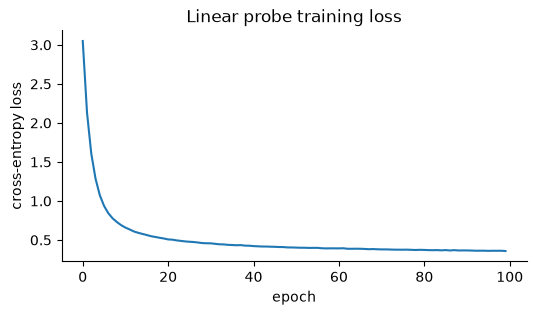

In [18]:
class LinearProbe(nn.Module):
    def __init__(self, input_dim, n_classes=10):
        super().__init__()
        self.classifier = nn.Linear(input_dim, n_classes)

    def forward(self, x):
        return self.classifier(x)

# Freeze the autoencoder encoder. The probe can learn, but the representation cannot change.
for parameter in autoencoder.encoder.parameters():
    parameter.requires_grad = False

autoencoder.eval()
with torch.no_grad():
    Z_train = autoencoder.encoder(X_train)
    Z_test = autoencoder.encoder(X_test)

probe_loader = DataLoader(TensorDataset(Z_train, y_train), batch_size=128, shuffle=True)
probe = LinearProbe(input_dim=latent_dim, n_classes=10)
probe_optimizer = torch.optim.Adam(probe.parameters(), lr=1e-2)
probe_loss = nn.CrossEntropyLoss()

probe_history = []
for epoch in range(100):
    probe.train()
    epoch_loss = 0.0
    for batch_z, batch_y in probe_loader:
        probe_optimizer.zero_grad()
        logits = probe(batch_z)
        loss = probe_loss(logits, batch_y)
        loss.backward()
        probe_optimizer.step()
        epoch_loss += loss.item() * batch_z.size(0)
    probe_history.append(epoch_loss / len(probe_loader.dataset))

probe.eval()
with torch.no_grad():
    predicted = probe(Z_test).argmax(dim=1)

probe_accuracy = accuracy_score(y_test.numpy(), predicted.numpy())
print(f'Linear probe accuracy on frozen autoencoder features: {probe_accuracy:.3f}')

plt.figure(figsize=(6, 3))
plt.plot(probe_history)
plt.xlabel('epoch')
plt.ylabel('cross-entropy loss')
plt.title('Linear probe training loss')
plt.show()

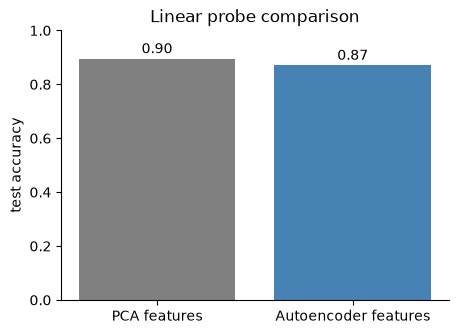

Linear probe accuracy on PCA features: 0.896
Linear probe accuracy on autoencoder features: 0.871


In [19]:
# Compare the learned autoencoder representation with PCA features of the same dimension.
pca_probe = PCA(n_components=latent_dim, random_state=0)
Z_train_pca = torch.tensor(pca_probe.fit_transform(X_train.numpy()), dtype=torch.float32)
Z_test_pca = torch.tensor(pca_probe.transform(X_test.numpy()), dtype=torch.float32)

pca_probe_model = LinearProbe(input_dim=latent_dim, n_classes=10)
pca_probe_optimizer = torch.optim.Adam(pca_probe_model.parameters(), lr=1e-2)
pca_probe_loader = DataLoader(TensorDataset(Z_train_pca, y_train), batch_size=128, shuffle=True)

for epoch in range(100):
    pca_probe_model.train()
    for batch_z, batch_y in pca_probe_loader:
        pca_probe_optimizer.zero_grad()
        logits = pca_probe_model(batch_z)
        loss = probe_loss(logits, batch_y)
        loss.backward()
        pca_probe_optimizer.step()

pca_probe_model.eval()
with torch.no_grad():
    predicted_pca = pca_probe_model(Z_test_pca).argmax(dim=1)

pca_probe_accuracy = accuracy_score(y_test.numpy(), predicted_pca.numpy())

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['PCA features', 'Autoencoder features'], [pca_probe_accuracy, probe_accuracy], color=['gray', 'steelblue'])
ax.set_ylim(0, 1)
ax.set_ylabel('test accuracy')
ax.set_title('Linear probe comparison')
for i, value in enumerate([pca_probe_accuracy, probe_accuracy]):
    ax.text(i, value + 0.02, f'{value:.2f}', ha='center')
plt.show()

print(f'Linear probe accuracy on PCA features: {pca_probe_accuracy:.3f}')
print(f'Linear probe accuracy on autoencoder features: {probe_accuracy:.3f}')

### Discussion: how linear probes are used in SSL

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5a_DimReduction.ipynb#scrollTo=ex-representation-evaluation)

Linear probes are popular in self-supervised learning because they help separate two questions:

1. **Did pretraining learn a useful representation?**
2. **Can a simple downstream model access task-relevant information from that representation?**

If the frozen representation plus a linear classifier works well, then the representation likely made important structure explicit. If it performs poorly, the representation may not contain the right information, or the information may be present but not linearly accessible.

A linear probe is not the final goal. It is a diagnostic. In many real applications, researchers pretrain a large model with SSL, evaluate it with a linear probe, and then fine-tune it for a specific downstream task.

### Exercise: representation evaluation

1. Compare the PCA probe accuracy and autoencoder probe accuracy.
2. Does better reconstruction necessarily imply better classification?
3. What would change if we trained the encoder using labels?
4. What would change if we allowed the encoder to update during probe training?


## Synthesis exercise: choosing a representation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5a_DimReduction.ipynb#scrollTo=ex-choosing-representation)

For each scenario, fill in the final column of the table. The goal is not just to name a method. The goal is to explain **why that representation matches the learning problem**.

Use this sentence frame if helpful:

> I would use ___ because this task needs to preserve ___, and this method is designed to ___ . I would be cautious about ___ .

| Scenario | Goal | What the representation should preserve | Possible methods | Your choice and reason |
|---|---|---|---|---|
| Compress image features before storage | Low reconstruction error | Major visual structure with fewer numbers | PCA, autoencoder |  |
| Visualize possible groups in nonlinear data | Human inspection | Local neighborhoods or curved structure | Isomap, t-SNE, kernel PCA |  |
| Build interpretable reduced features | Explanation | Axes that can be related back to original variables | PCA, sparse PCA |  |
| Separate known classes | Classification | Directions that separate labels | LDA, supervised neural features |  |
| Pretrain without labels, then evaluate with labels | Transferable representation | Information useful for downstream tasks | SSL encoder + linear probe |  |

After completing the table, choose one row and answer:

1. What structure does your chosen representation preserve?
2. What structure might it distort or hide?
3. What diagnostic, metric, or visualization would you use to evaluate it?
4. If labels are involved, are they used to learn the representation, evaluate it, or both?


## Module summary

In this module, we used **representation learning** as the unifying lens.

Key ideas covered:

- A representation is the form in which data are made available to a model.
- Dimensionality reduction is one way to learn or choose a representation, but representation learning is broader than reducing dimensions.
- Covariance describes the geometry of variation in data.
- PCA learns linear directions that preserve maximum variance.
- Scaling changes PCA because it changes which variations count as large.
- PCA can be used for visualization, compression, and denoising.
- Sparse PCA, LDA, and kernel PCA modify the representation objective in different ways.
- Manifold learning methods such as Isomap and t-SNE focus on neighborhood structure rather than global variance.
- Isomap uses a neighborhood graph to approximate geodesic distances along a manifold.
- t-SNE builds a probabilistic neighborhood map and is best treated as a visualization tool.
- Autoencoders learn nonlinear latent representations by reconstructing their inputs.
- Self-supervised learning creates training signals from the data itself rather than relying on human labels.
- Linear probes evaluate whether a frozen representation makes task-relevant information easy for a simple classifier to access.

The recurring question is:

> What structure should this representation preserve, what might it distort, and how will we know whether it helped?
